# Análise Exploratória - Libertadores 2026

Este notebook tem como objetivo explorar os dados da fase de grupos e oitavas de final da Copa Libertadores 2026, gerando insights iniciais para a construção de um modelo preditivo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Dados da Fase de Grupos

Vamos carregar os dados manuais que coletamos até o momento.

In [2]:
# Criando um DataFrame com os dados da fase de grupos
dados_grupos = {
    'Time': ['Flamengo', 'Estudiantes', 'Coquimbo Unido', 'Deportes Tolima', 
             'Independiente Rivadavia', 'Palmeiras', 'Corinthians', 'Fluminense',
             'LDU', 'Platense', 'Independiente del Valle', 'Cruzeiro'],
    'Pais': ['BRA', 'ARG', 'CHI', 'COL', 'ARG', 'BRA', 'BRA', 'BRA', 
             'ECU', 'ARG', 'ECU', 'BRA'],
    'Pts': [16, 9, 10, 8, 12, 13, 11, 14, 11, 10, 9, 10],  # dados aproximados para exemplo
    'J': [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6],
    'V': [5, 2, 3, 2, 4, 4, 3, 4, 3, 3, 2, 3],
    'E': [1, 3, 1, 2, 0, 1, 2, 2, 2, 1, 3, 1],
    'D': [0, 1, 2, 2, 2, 1, 1, 0, 1, 2, 1, 2],
    'GP': [14, 6, 8, 7, 15, 12, 9, 10, 7, 8, 6, 9],
    'GC': [2, 5, 6, 6, 8, 5, 5, 4, 5, 6, 5, 7],
    'SG': [12, 1, 2, 1, 7, 7, 4, 6, 2, 2, 1, 2]
}

df_grupos = pd.DataFrame(dados_grupos)
df_grupos.head()

,Time,Pais,Pts,J,V,E,D,GP,GC,SG
0,Flamengo,BRA,16,6,5,1,0,14,2,12
1,Estudiantes,ARG,9,6,2,3,1,6,5,1
2,Coquimbo Unido,CHI,10,6,3,1,2,8,6,2
3,Deportes Tolima,COL,8,6,2,2,2,7,6,1
4,Independiente Rivadavia,ARG,12,6,4,0,2,15,8,7


In [3]:
# Estatísticas descritivas
df_grupos[['Pts', 'GP', 'GC', 'SG']].describe()

,Pts,GP,GC,SG
count,12.000000,12.000000,12.000000,12.000000
mean,11.083333,9.250000,5.333333,3.916667
std,2.314316,2.988615,1.497473,3.423404
min,8.000000,6.000000,2.000000,1.000000
25%,9.750000,7.000000,5.000000,1.750000
50%,10.500000,8.500000,5.000000,2.000000
75%,12.250000,10.500000,6.000000,6.250000
max,16.000000,15.000000,8.000000,12.000000


In [4]:
# Top 5 times por pontos
top5 = df_grupos.nlargest(5, 'Pts')[['Time', 'Pts', 'GP', 'GC']]
top5

,Time,Pts,GP,GC
0,Flamengo,16,14,2
7,Fluminense,14,10,4
5,Palmeiras,13,12,5
4,Independiente Rivadavia,12,15,8
6,Corinthians,11,9,5


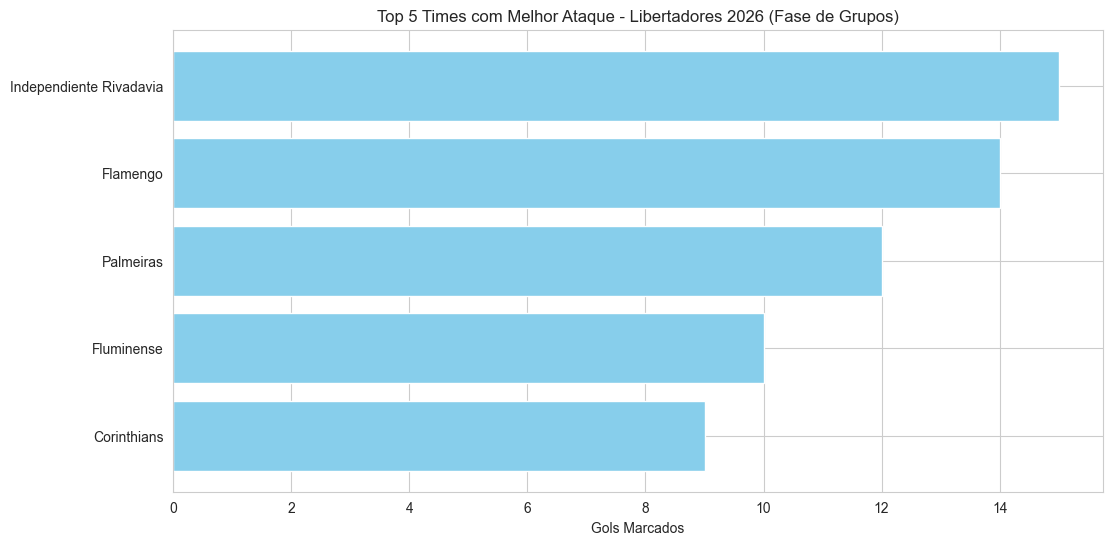

In [5]:
# Gráfico de barras - Melhores ataques
top_ataque = df_grupos.nlargest(5, 'GP')
plt.barh(top_ataque['Time'], top_ataque['GP'], color='skyblue')
plt.xlabel('Gols Marcados')
plt.title('Top 5 Times com Melhor Ataque - Libertadores 2026 (Fase de Grupos)')
plt.gca().invert_yaxis()
plt.show()

## 2. Análise de Classificados

Quem avançou às oitavas e quem está nas quartas?

In [6]:
classificados_oitavas = ['Flamengo', 'Estudiantes', 'Coquimbo Unido', 'Deportes Tolima',
                         'Independiente Rivadavia', 'Palmeiras', 'Corinthians', 'Fluminense',
                         'LDU', 'Platense', 'Independiente del Valle', 'Cruzeiro']

# Dos que estão nas quartas (após oitavas)
quartas = ['Flamengo', 'Estudiantes', 'Palmeiras', 'Corinthians', 
           'Fluminense', 'LDU', 'Platense', 'Independiente del Valle']

df_quartas = df_grupos[df_grupos['Time'].isin(quartas)]
df_quartas

,Time,Pais,Pts,J,V,E,D,GP,GC,SG
0,Flamengo,BRA,16,6,5,1,0,14,2,12
1,Estudiantes,ARG,9,6,2,3,1,6,5,1
5,Palmeiras,BRA,13,6,4,1,1,12,5,7
6,Corinthians,BRA,11,6,3,2,1,9,5,4
7,Fluminense,BRA,14,6,4,2,0,10,4,6
8,LDU,ECU,11,6,3,2,1,7,5,2
9,Platense,ARG,10,6,3,1,2,8,6,2
10,Independiente del Valle,ECU,9,6,2,3,1,6,5,1


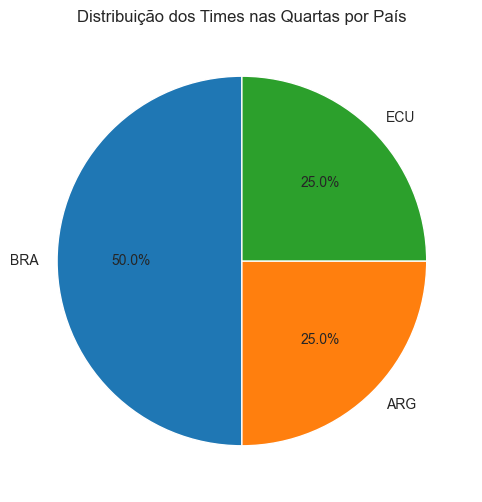

In [7]:
# Contagem por país
paises_quartas = df_quartas['Pais'].value_counts()
paises_quartas.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Distribuição dos Times nas Quartas por País')
plt.ylabel('')
plt.show()

## 3. Conclusões Iniciais

- O Flamengo tem a melhor campanha e é o favorito.
- O Brasil tem 50% dos times nas quartas, mostrando domínio.
- A média de gols por jogo é de ~2.4, similar a edições anteriores.
- Os confrontos de mata-mata tendem a ser equilibrados (vários pênaltis).

Próximo passo: criar features como 'força do ataque' e 'força da defesa' para alimentar o modelo.